In [64]:
import pandas as pd
import numpy as np
df = pd.read_csv("yield_df.csv")
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [65]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.rename(columns={"hg/ha_yield": "Yield"})

In [66]:
df.isnull().sum()

Area                             0
Item                             0
Year                             0
Yield                            0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [67]:
df = df.dropna()

In [68]:
X = df.drop("Yield", axis=1)
y = df["Yield"]

In [69]:
import joblib

yield_features = X.columns
joblib.dump(yield_features, "yield_features.pkl")

['yield_features.pkl']

In [70]:
X = pd.get_dummies(X, drop_first=True)

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [72]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [73]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Linear R2:", r2_score(y_test, y_pred_lr))
print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear R2: 0.7551423617508117
Linear RMSE: 42144.002982873004


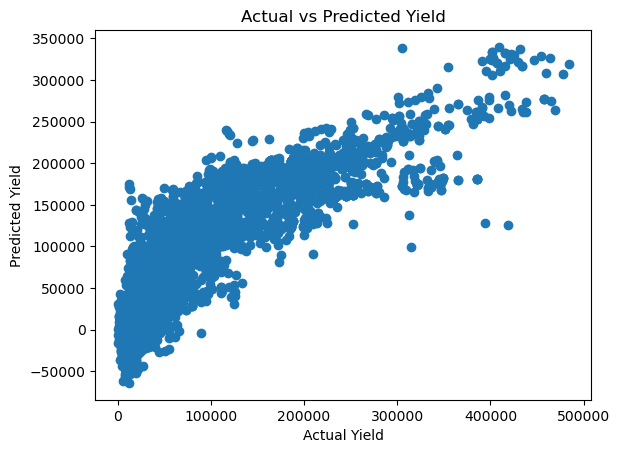

In [74]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

In [75]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [76]:
from sklearn.ensemble import RandomForestRegressor

rf_new = RandomForestRegressor(n_estimators=100, random_state=42)

rf_new.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
importances = rf_new.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
106,Item_Potatoes,0.369278
107,"Item_Rice, paddy",0.074790
2,pesticides_tonnes,0.070673
110,Item_Sweet potatoes,0.065419
45,Area_India,0.056951
3,avg_temp,0.043567
1,average_rain_fall_mm_per_year,0.042398
0,Year,0.032857
104,Item_Maize,0.027034
111,Item_Wheat,0.021893


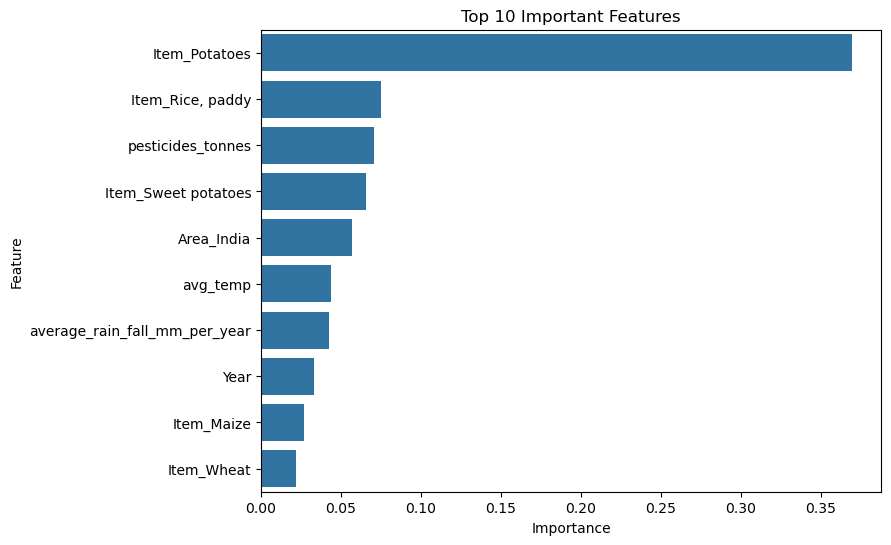

In [78]:
plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [79]:
selected_features = [
    "average_rain_fall_mm_per_year",
    "avg_temp"
]

In [80]:
X_sparse = df[selected_features]
y = df["Yield"]

In [81]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sparse, y, test_size=0.2, random_state=42
)

In [82]:
X_sparse = X[[
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "Year"
]]
y_sparse = y

In [83]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sparse, y_sparse, test_size=0.2, random_state=42
)

In [84]:
from sklearn.ensemble import RandomForestRegressor

rf_sparse = RandomForestRegressor(n_estimators=100, random_state=42)

rf_sparse.fit(X_train_s, y_train_s)

RandomForestRegressor(random_state=42)

In [85]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred_sparse = rf_sparse.predict(X_test_s)

r2_sparse = r2_score(y_test_s, y_pred_sparse)
rmse_sparse = np.sqrt(mean_squared_error(y_test_s, y_pred_sparse))

print("Sparse R2:", r2_sparse)
print("Sparse RMSE:", rmse_sparse)

Sparse R2: -0.2027728454683353
Sparse RMSE: 93405.13731316684


In [86]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predict using full model
y_pred_rf = rf.predict(X_test)

# Calculate metrics
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Full Model R2:", r2_rf)
print("Full Model RMSE:", rmse_rf)

Full Model R2: 0.9874701196641542
Full Model RMSE: 9533.50102482927


In [87]:
y_pred_sparse = rf_sparse.predict(X_test_s)

r2_sparse = r2_score(y_test_s, y_pred_sparse)

print("Sparse Model R2:", r2_sparse)

Sparse Model R2: -0.2027728454683353


In [88]:
print("Full Model R2:", r2_rf)
print("Sparse Model R2:", r2_sparse)

Full Model R2: 0.9874701196641542
Sparse Model R2: -0.2027728454683353


In [89]:
features = [
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "Year",
    "Item"
]

X_mod = df[features]
y = df["Yield"]

X_mod = pd.get_dummies(X_mod, drop_first=True)

In [90]:
from sklearn.model_selection import train_test_split

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mod, y, test_size=0.2, random_state=42
)

In [91]:
from sklearn.ensemble import RandomForestRegressor

rf_mod = RandomForestRegressor(n_estimators=100, random_state=42)
rf_mod.fit(X_train_m, y_train_m)

y_pred_mod = rf_mod.predict(X_test_m)

In [92]:
from sklearn.metrics import r2_score

r2_mod = r2_score(y_test_m, y_pred_mod)
print("Moderate Sparse R2:", r2_mod)

Moderate Sparse R2: 0.9835359648407711


In [93]:
features_sparse = [
    "average_rain_fall_mm_per_year",
    "avg_temp"
]

X_sparse = df[features_sparse]
y = df["Yield"]

from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sparse, y, test_size=0.2, random_state=42
)

In [94]:
from sklearn.ensemble import RandomForestRegressor

rf_sparse = RandomForestRegressor(n_estimators=100, random_state=42)
rf_sparse.fit(X_train_s, y_train_s)

y_pred_sparse = rf_sparse.predict(X_test_s)

In [95]:
from sklearn.metrics import r2_score

r2_sparse = r2_score(y_test_s, y_pred_sparse)
print("Extreme Sparse R2:", r2_sparse)

Extreme Sparse R2: -0.14929262104466168


In [96]:
print("Full Model R2:", r2_rf)
print("Moderate Sparse R2:", r2_mod)
print("Extreme Sparse R2:", r2_sparse)

Full Model R2: 0.9874701196641542
Moderate Sparse R2: 0.9835359648407711
Extreme Sparse R2: -0.14929262104466168


In [97]:
features_full = [
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "Year",
    "Item",
    "pesticides_tonnes",
    "Area"
]

X = df[features_full]
y = df["Yield"]

X = pd.get_dummies(X, drop_first=True)

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [99]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [100]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Full Model R2:", r2_rf)
print("Full Model RMSE:", rmse_rf)

Full Model R2: 0.987552519714148
Full Model RMSE: 9502.1018126193


In [101]:
print("Full Model R2:", r2_rf)
print("Moderate Sparse R2:", r2_mod)
print("Extreme Sparse R2:", r2_sparse)

Full Model R2: 0.987552519714148
Moderate Sparse R2: 0.9835359648407711
Extreme Sparse R2: -0.14929262104466168


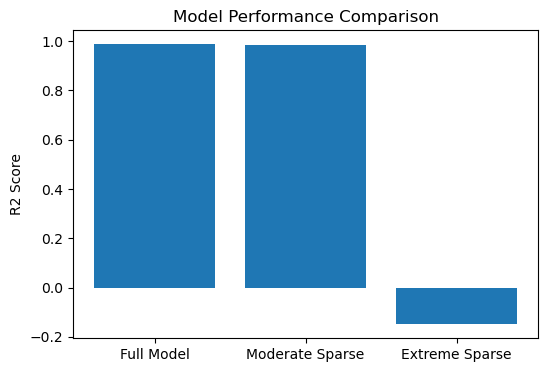

In [102]:
import matplotlib.pyplot as plt

models = ["Full Model", "Moderate Sparse", "Extreme Sparse"]
scores = [0.9875, 0.9835, -0.149]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.ylabel("R2 Score")
plt.title("Model Performance Comparison")
plt.show()

In [103]:
import joblib

joblib.dump(rf, "crop_yield_model.pkl")

['crop_yield_model.pkl']

In [104]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

In [105]:
df = pd.read_csv("yield_df.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.rename(columns={"hg/ha_yield": "Yield"})

In [106]:
le_area = LabelEncoder()
le_crop = LabelEncoder()

df["Area"] = le_area.fit_transform(df["Area"])
df["Item"] = le_crop.fit_transform(df["Item"])

In [107]:
X = df.drop("Yield", axis=1)
y = df["Yield"]

In [108]:
import joblib

# Save the feature order
joblib.dump(X.columns, "yield_feature_order.pkl")

['yield_feature_order.pkl']

In [109]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

joblib.dump(model, "crop_yield_model.pkl")

['crop_yield_model.pkl']

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [111]:
joblib.dump(model, "crop_yield_model.pkl")
joblib.dump(le_area, "area_encoder.pkl")
joblib.dump(le_crop, "crop_encoder.pkl")

['crop_encoder.pkl']

In [112]:
import os;
os.getcwd()

'/Users/Anagha/Mini Project'

In [113]:
X = df.drop(["Yield", "Year"], axis=1)
y = df["Yield"]

In [114]:
X = df.drop(["Yield", "Year"], axis=1)
y = df["Yield"]

In [115]:
X = pd.get_dummies(X)

In [116]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [117]:
from sklearn.ensemble import RandomForestRegressor

rf_new = RandomForestRegressor(n_estimators=100, random_state=42)
rf_new.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [118]:
from sklearn.metrics import r2_score

y_pred = rf_new.predict(X_test)

r2_new = r2_score(y_test, y_pred)

print("R2 without Year:", r2_new)

R2 without Year: 0.9729083242793309


In [119]:
X_mod = df.drop(["Yield", "Year", "Area"], axis=1)

X_mod = pd.get_dummies(X_mod)

In [120]:
X_env = df[[
    "average_rain_fall_mm_per_year",
    "avg_temp"
]]

y_env = df["Yield"]

In [121]:
from sklearn.model_selection import train_test_split

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_env, y_env, test_size=0.2, random_state=42
)

In [122]:
from sklearn.ensemble import RandomForestRegressor

rf_env = RandomForestRegressor(n_estimators=100, random_state=42)

rf_env.fit(X_train_e, y_train_e)

RandomForestRegressor(random_state=42)

In [123]:
y_pred_env = rf_env.predict(X_test_e)

In [124]:
from sklearn.metrics import r2_score

r2_env = r2_score(y_test_e, y_pred_env)

print("Environmental Only R2:", r2_env)

Environmental Only R2: -0.14929262104466168


In [125]:
features = [
    "average_rain_fall_mm_per_year",
    "avg_temp",
    "pesticides_tonnes",
    "Item",
    "Area"
]

X = df[features]
y = df["Yield"]

In [126]:
X = pd.get_dummies(X)

In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [128]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [129]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [130]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

print("Final R2:", r2_score(y_test, y_pred))

Final R2: 0.9728847910914854


In [131]:
import joblib

joblib.dump(model, "crop_yield_model.pkl")
joblib.dump(X.columns, "yield_features.pkl")

['yield_features.pkl']